Crop Accuracy: 0.9634551495016611
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       130
           1       1.00      1.00      1.00        25
           2       0.69      0.69      0.69        16
           3       1.00      1.00      1.00        25
           4       0.86      0.86      0.86        35
           5       0.92      0.76      0.83        79
           6       0.96      1.00      0.98        70
           7       0.67      1.00      0.80         2
           8       0.62      1.00      0.77        20
           9       1.00      0.98      0.99        62
          10       1.00      1.00      1.00         9
          11       1.00      1.00      1.00       202
          12       1.00      1.00      1.00        25
          13       1.00      1.00      1.00        11
          14       0.91      1.00      0.95        20
          15       1.00      0.98      0.99       172

    accuracy                           0.96   

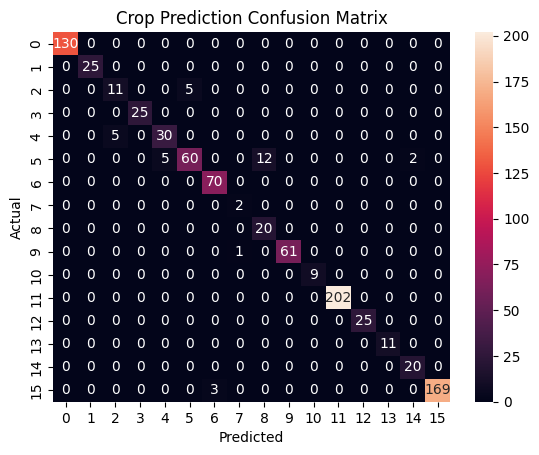

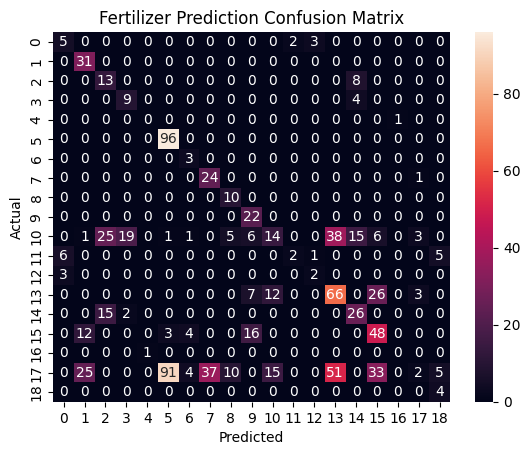

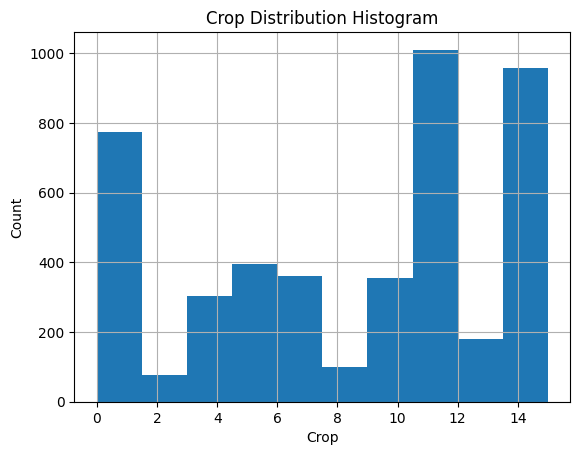

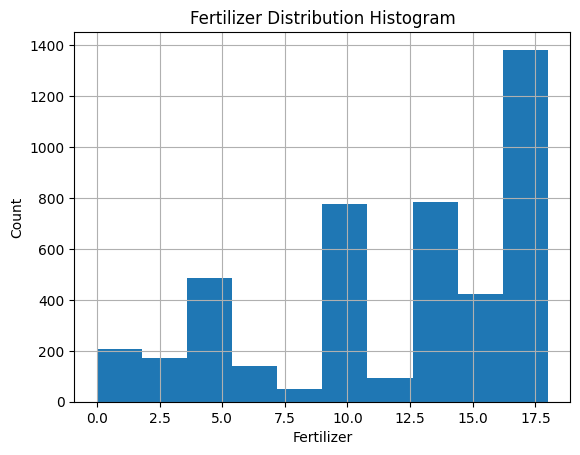

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Load dataset
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Crop and fertilizer dataset.csv")

# Remove link column
if "Link" in data.columns:
    data = data.drop("Link", axis=1)

# Encode categorical columns
le = LabelEncoder()
for col in ["District_Name", "Soil_color", "Crop", "Fertilizer"]:
    data[col] = le.fit_transform(data[col])

# ----------- CROP PREDICTION -----------
X = data.drop(["Crop", "Fertilizer"], axis=1)
y = data["Crop"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_crop = SVC(kernel="rbf", class_weight="balanced")
model_crop.fit(X_train, y_train)

y_pred = model_crop.predict(X_test)

print("Crop Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


# ----------- FERTILIZER PREDICTION -----------
X2 = data.drop("Fertilizer", axis=1)
y2 = data["Fertilizer"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

model_fert = SVC(kernel="linear", class_weight="balanced")
model_fert.fit(X_train2, y_train2)

y_pred2 = model_fert.predict(X_test2)

print("Fertilizer Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2, zero_division=0))


# CONFUSION MATRIX - CROP
# ==============================
cm_crop = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm_crop, annot=True, fmt='d')
plt.title("Crop Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==============================
# CONFUSION MATRIX - FERTILIZER
# ==============================
cm_fert = confusion_matrix(y_test2, y_pred2)

plt.figure()
sns.heatmap(cm_fert, annot=True, fmt='d')
plt.title("Fertilizer Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==============================
# HISTOGRAM - CROP DISTRIBUTION
# ==============================
plt.figure()
data["Crop"].hist()
plt.title("Crop Distribution Histogram")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()


# ==============================
# HISTOGRAM - FERTILIZER DISTRIBUTION
# ==============================
plt.figure()
data["Fertilizer"].hist()
plt.title("Fertilizer Distribution Histogram")
plt.xlabel("Fertilizer")
plt.ylabel("Count")
plt.show()

SVM Crop Prediction Accuracy: 0.3333333333333333
Naive Bayes Fertilizer Accuracy: 0.3333333333333333

Prediction for Given Input:
Predicted Crop: Sugarcane
Recommended Fertilizer: Urea


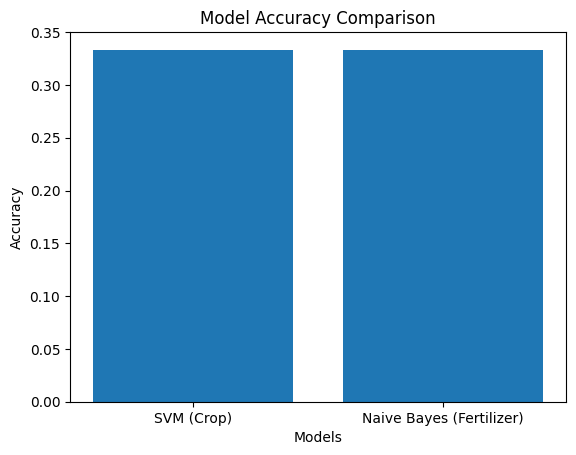

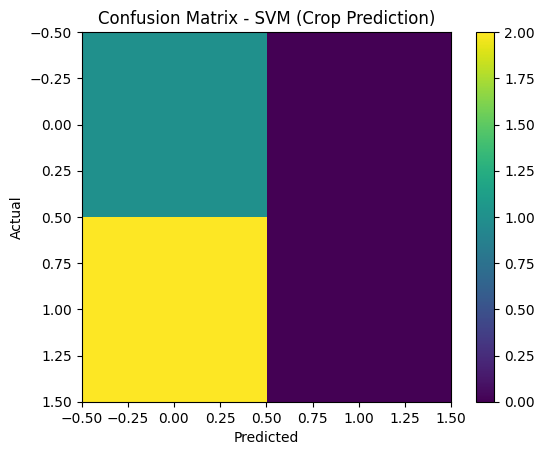

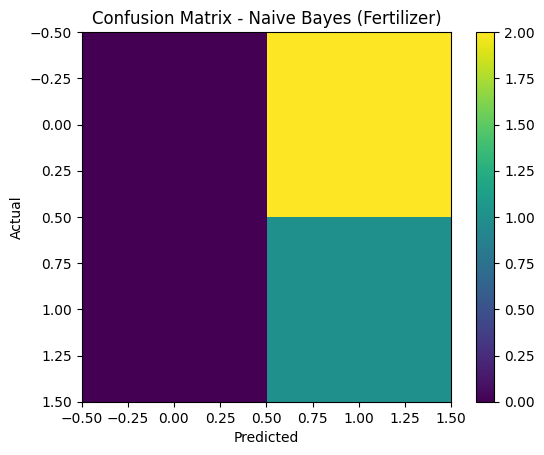

In [ ]:
# =====================================================
# Crop & Fertilizer Prediction System
# Using SVM and Naive Bayes
# =====================================================

# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# =====================================================
# Sample Dataset (Replace with your CSV file if needed)
# =====================================================

data = {
    'District_Name': ['Kolhapur','Pune','Satara','Nashik','Kolhapur',
                      'Pune','Satara','Nashik'],
    'Soil_color': ['Black','Red','Black','Alluvial','Black',
                   'Red','Black','Alluvial'],
    'Nitrogen': [75, 60, 80, 50, 90, 55, 85, 45],
    'Phosphorus': [50, 40, 60, 30, 55, 35, 65, 25],
    'Potassium': [100, 80, 110, 60, 120, 75, 115, 55],
    'pH': [6.5, 7.0, 6.8, 7.5, 6.4, 7.1, 6.7, 7.4],
    'Rainfall': [1000, 800, 1200, 600, 1100, 850, 1250, 650],
    'Temperature': [20, 25, 22, 30, 21, 26, 23, 29],
    'Crop': ['Sugarcane','Wheat','Sugarcane','Millet',
             'Sugarcane','Wheat','Sugarcane','Millet'],
    'Fertilizer': ['Urea','DAP','Urea','Organic',
                   'Urea','DAP','Urea','Organic'],
    'Link': ['https://youtu.be/2t5Am0xLTOo']*8
}

df = pd.DataFrame(data)

# =====================================================
# Remove Unnecessary Column
# =====================================================
df.drop('Link', axis=1, inplace=True)

# =====================================================
# Encode Categorical Data
# =====================================================
le_district = LabelEncoder()
df['District_Name'] = le_district.fit_transform(df['District_Name'])

le_soil = LabelEncoder()
df['Soil_color'] = le_soil.fit_transform(df['Soil_color'])

le_crop = LabelEncoder()
df['Crop'] = le_crop.fit_transform(df['Crop'])

le_fert = LabelEncoder()
df['Fertilizer'] = le_fert.fit_transform(df['Fertilizer'])

# =====================================================
# Feature Selection
# =====================================================
X = df[['District_Name','Soil_color','Nitrogen',
        'Phosphorus','Potassium','pH',
        'Rainfall','Temperature']]

y_crop = df['Crop']
y_fert = df['Fertilizer']

# =====================================================
# Train-Test Split
# =====================================================
X_train, X_test, y_crop_train, y_crop_test = train_test_split(
    X, y_crop, test_size=0.3, random_state=42)

_, _, y_fert_train, y_fert_test = train_test_split(
    X, y_fert, test_size=0.3, random_state=42)

# =====================================================
# Convert to NumPy BEFORE scaling (No warning method)
# =====================================================
X_train = X_train.values
X_test = X_test.values

# =====================================================
# Feature Scaling
# =====================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =====================================================
# Train Models
# =====================================================
# SVM for Crop Prediction
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_crop_train)

# Naive Bayes for Fertilizer Recommendation
nb_model = GaussianNB()
nb_model.fit(X_train, y_fert_train)

# =====================================================
# Model Accuracy
# =====================================================
crop_pred = svm_model.predict(X_test)
fert_pred = nb_model.predict(X_test)

print("SVM Crop Prediction Accuracy:",
      accuracy_score(y_crop_test, crop_pred))

print("Naive Bayes Fertilizer Accuracy:",
      accuracy_score(y_fert_test, fert_pred))

# =====================================================
# New Farmer Input Prediction
# =====================================================
new_input = np.array([[
    le_district.transform(['Kolhapur'])[0],
    le_soil.transform(['Black'])[0],
    75, 50, 100, 6.5, 1000, 20
]])

# Scale new input
new_input_scaled = scaler.transform(new_input)

# Predict Crop
crop_prediction = svm_model.predict(new_input_scaled)
crop_result = le_crop.inverse_transform(crop_prediction)

# Predict Fertilizer
fert_prediction = nb_model.predict(new_input_scaled)
fert_result = le_fert.inverse_transform(fert_prediction)

print("\nPrediction for Given Input:")
print("Predicted Crop:", crop_result[0])
print("Recommended Fertilizer:", fert_result[0])

# 1️⃣ Accuracy Comparison Graph
# -----------------------------
svm_accuracy = accuracy_score(y_crop_test, crop_pred)
nb_accuracy = accuracy_score(y_fert_test, fert_pred)

plt.figure()
plt.bar(['SVM (Crop)', 'Naive Bayes (Fertilizer)'],
        [svm_accuracy, nb_accuracy])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


# -----------------------------
# 2️⃣ Confusion Matrix - SVM
# -----------------------------
cm_svm = confusion_matrix(y_crop_test, crop_pred)

plt.figure()
plt.imshow(cm_svm)
plt.title("Confusion Matrix - SVM (Crop Prediction)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


# -----------------------------
# 3️⃣ Confusion Matrix - Naive Bayes
# -----------------------------
cm_nb = confusion_matrix(y_fert_test, fert_pred)

plt.figure()
plt.imshow(cm_nb)
plt.title("Confusion Matrix - Naive Bayes (Fertilizer)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()